GPU 확인 및 패키지 설치

In [1]:
import torch
print('GPU 사용 가능:', torch.cuda.is_available())
print('GPU 이름:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

!pip install -q gradio

GPU 사용 가능: True
GPU 이름: Tesla T4


전역 상수 및 랜덤 시드 고정

In [2]:
import random
import numpy as np
import torch

# ── 전역 상수 (모든 셀에서 참조) ─────────────────────────────────
SEED      = 42
BASE_PATH = '/content/gesture/leapGestRecog'
NUM_CLASSES = 10
IMG_SIZE    = 300
BATCH_SIZE  = 32

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── 시드 고정 ────────────────────────────────────────────────────
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f'전역 상수 및 랜덤 시드 고정 완료 (SEED={SEED})')

전역 상수 및 랜덤 시드 고정 완료 (SEED=42)


한글 폰트

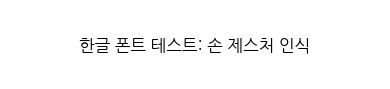

한글 폰트 설정 완료


In [3]:
!apt-get install -y fonts-nanum > /dev/null 2>&1

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

nanum_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(nanum_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(4, 1))
ax.text(0.5, 0.5, '한글 폰트 테스트: 손 제스처 인식', ha='center', va='center', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()
print('한글 폰트 설정 완료')

API키 업로드

In [4]:
from google.colab import files
import os

files.upload()  # kaggle.json 선택

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print('Kaggle 인증 완료!')

Saving kaggle.json to kaggle.json
Kaggle 인증 완료!


데이터셋 다운로드

In [5]:
!kaggle datasets download -d gti-upm/leapgestrecog -p /content/gesture --unzip

import os

subjects = sorted(os.listdir(BASE_PATH))
print(f'피험자 수: {len(subjects)}명 -> {subjects}')

classes = sorted(os.listdir(os.path.join(BASE_PATH, subjects[0])))
print(f'제스처 클래스 ({len(classes)}개): {classes}')

Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [00:19<00:00, 117MB/s]

피험자 수: 10명 -> ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09']
제스처 클래스 (10개): ['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


데이터 샘플 시각화

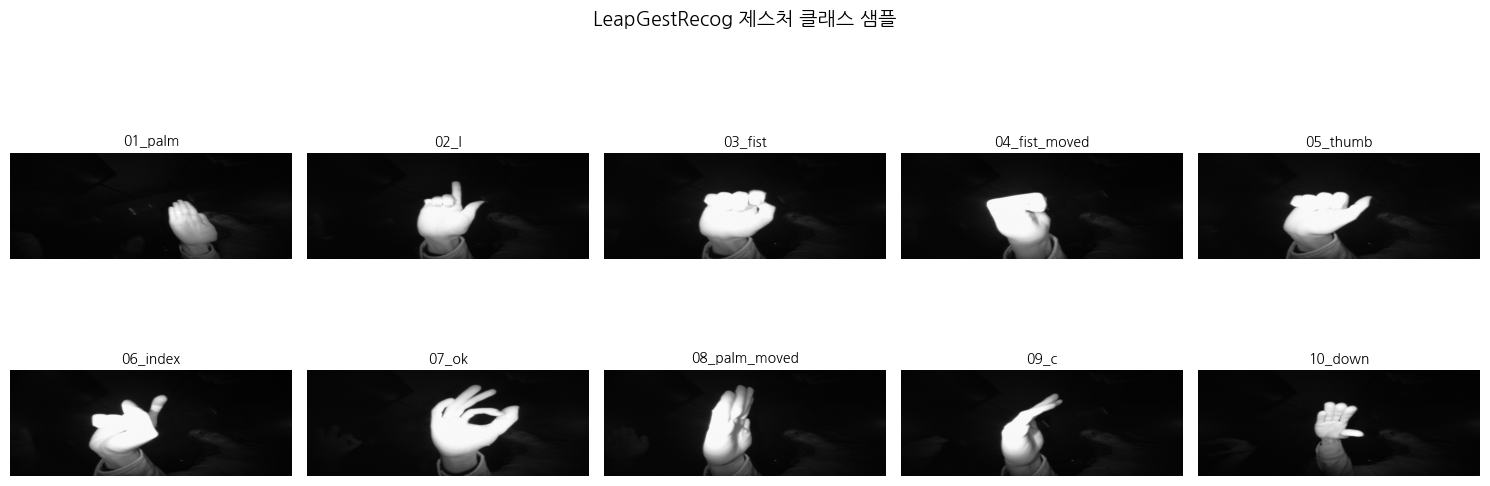

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

subjects     = sorted(os.listdir(BASE_PATH))
subject_path = os.path.join(BASE_PATH, subjects[0])
classes      = sorted(os.listdir(subject_path))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, cls in enumerate(classes[:10]):
    cls_path = os.path.join(subject_path, cls)
    img_file = sorted(os.listdir(cls_path))[0]
    img = mpimg.imread(os.path.join(cls_path, img_file))
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(cls, fontsize=10)
    axes[idx].axis('off')

plt.suptitle('LeapGestRecog 제스처 클래스 샘플', fontsize=14)
plt.tight_layout()
plt.show()

클래스 분포 확인

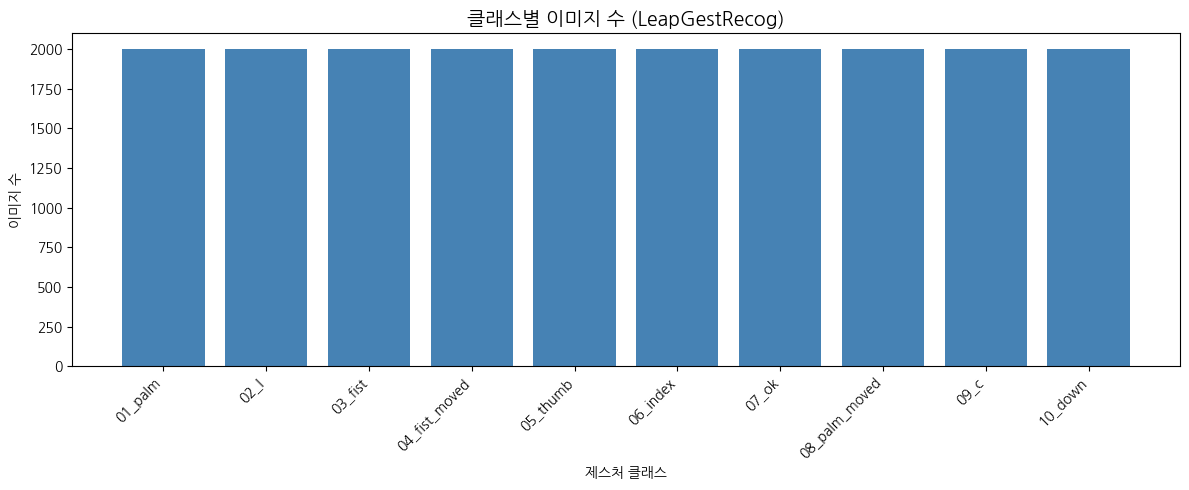

총 이미지 수: 20,000장
클래스 수: 10개
클래스 균형: 최소 2,000 / 최대 2,000


In [7]:
import matplotlib.pyplot as plt
from collections import defaultdict
import os

class_counts = defaultdict(int)

for subject in sorted(os.listdir(BASE_PATH)):          # ← sorted 추가
    subject_path = os.path.join(BASE_PATH, subject)
    if not os.path.isdir(subject_path):
        continue
    for cls in sorted(os.listdir(subject_path)):       # ← sorted 추가
        cls_path = os.path.join(subject_path, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] += len(os.listdir(cls_path))

sorted_classes = sorted(class_counts.keys())
sorted_counts  = [class_counts[c] for c in sorted_classes]

plt.figure(figsize=(12, 5))
plt.bar(sorted_classes, sorted_counts, color='steelblue')
plt.title('클래스별 이미지 수 (LeapGestRecog)', fontsize=14)
plt.xlabel('제스처 클래스')
plt.ylabel('이미지 수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'총 이미지 수: {sum(class_counts.values()):,}장')
print(f'클래스 수: {len(class_counts)}개')
print(f'클래스 균형: 최소 {min(sorted_counts):,} / 최대 {max(sorted_counts):,}')

Dataset 클래스 및 DataLoader

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import random
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

class LeapGestRecogDataset(Dataset):
    CLASSES = sorted(['01_palm','02_l','03_fist','04_fist_moved','05_thumb',
                      '06_index','07_ok','08_palm_moved','09_c','10_down'])

    def __init__(self, base_path, subjects, transform=None):
        self.transform    = transform
        self.classes      = self.CLASSES
        self.class_to_idx = {c: i for i, c in enumerate(self.CLASSES)}
        self.samples      = []
        for subj in subjects:
            for cls in self.CLASSES:
                cls_path = os.path.join(base_path, subj, cls)
                if not os.path.isdir(cls_path): continue
                for fname in sorted(os.listdir(cls_path)):
                    self.samples.append(
                        (os.path.join(cls_path, fname), self.class_to_idx[cls])
                    )

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

train_subjects = ['00','01','02','03','04','05']
val_subjects   = ['06','07']
test_subjects  = ['08','09']

# ── 학습 증강 (강화) ──────────────────────────────────────────────
# 개선1: RandomHorizontalFlip 추가 (좌우 미러링 — 손 제스처에 유효)
# 개선2: translate=(0.05, 0.05) 활성화 (이전엔 None으로 무의미했음)
# 개선3: RandomErasing 추가 (occlusion 강건성)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=15, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = LeapGestRecogDataset(BASE_PATH, train_subjects, train_transform)
val_dataset   = LeapGestRecogDataset(BASE_PATH, val_subjects,   eval_transform)
test_dataset  = LeapGestRecogDataset(BASE_PATH, test_subjects,  eval_transform)

# ── Worker 시드 고정 (SEED 전역 상수에 직접 의존하지 않는 구조) ─────
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, persistent_workers=True,
    worker_init_fn=seed_worker, generator=g
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True, persistent_workers=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True, persistent_workers=True
)

print(f'학습  피험자: {train_subjects} -> {len(train_dataset):,}장')
print(f'검증  피험자: {val_subjects}   -> {len(val_dataset):,}장')
print(f'테스트 피험자: {test_subjects}  -> {len(test_dataset):,}장')
print(f'클래스 수: {len(train_dataset.classes)}개')

사용 디바이스: cuda
학습  피험자: ['00', '01', '02', '03', '04', '05'] -> 12,000장
검증  피험자: ['06', '07']   -> 4,000장
테스트 피험자: ['08', '09']  -> 4,000장
클래스 수: 10개


EfficientNet-B3 모델 로드

In [9]:
import torch
import torch.nn as nn
from torchvision import models

weights = models.EfficientNet_B3_Weights.DEFAULT
model   = models.efficientnet_b3(weights=weights)

# Classifier 수정: Dropout(0.4) + Linear(NUM_CLASSES) — 기본값(0.3)보다 약간 강화
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(model.classifier[1].in_features, NUM_CLASSES),
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'EfficientNet-B3 로드 완료')
print(f'전체 파라미터: {total_params:,} | 학습 가능: {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 167MB/s]


EfficientNet-B3 로드 완료
전체 파라미터: 10,711,602 | 학습 가능: 10,711,602


학습 및 평가 루프

In [10]:
import copy
import torch.optim as optim
import numpy as np
from torch.amp import autocast, GradScaler

# ── MixUp ────────────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.2):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1
    index = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[index], y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ── 평가 함수 (수정: eval_criterion 분리하여 명시) ────────────────
# train criterion: label_smoothing=0.1 (정규화 목적)
# eval  criterion: smoothing 없음 (실제 loss 수치 해석용)
# → 두 값은 스케일이 달라 직접 비교 불가 — 학습 곡선에서 acc로 판단할 것
train_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
eval_criterion  = nn.CrossEntropyLoss()

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            with autocast('cuda'):                             # ← AMP
                outputs = model(images)
                loss    = eval_criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total   += images.size(0)
    return total_loss / total, correct / total * 100

scaler       = GradScaler('cuda')                              # ← AMP scaler
best_val_acc = 0
best_weights = None
history      = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# ── 1단계: Backbone 고정, Classifier 워밍업 ──────────────────────
print('=' * 65)
print('1단계: Backbone 고정 — Classifier 워밍업 (5 epoch)')
print('-' * 65)

for param in model.parameters():            param.requires_grad = False
for param in model.classifier.parameters(): param.requires_grad = True

# 수정: AdamW 사용 (올바른 weight decay 분리)
optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(1, 6):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast('cuda'):
            outputs = model(images)
            loss    = train_criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)
        _, preds    = torch.max(outputs, 1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    tr_loss, tr_acc     = total_loss / total, correct / total * 100
    vl_loss, vl_acc     = evaluate(val_loader)
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss);   history['val_acc'].append(vl_acc)
    print(f'Epoch {epoch:>2} | TrainLoss: {tr_loss:.4f} | TrainAcc: {tr_acc:.2f}% | ValLoss: {vl_loss:.4f} | ValAcc: {vl_acc:.2f}%')

# ── 2단계: 전체 레이어 해제, Fine-tuning + MixUp ─────────────────
print('\n' + '=' * 65)
print('2단계: 전체 레이어 학습 — Fine-tuning + MixUp (patience=7)')
print('-' * 65)

for param in model.parameters(): param.requires_grad = True

# 수정1: AdamW 사용
# 수정2: 레이어별 LR 분리 — backbone은 낮은 LR, classifier는 높은 LR
optimizer = optim.AdamW([
    {'params': model.features.parameters(),    'lr': 1e-5},
    {'params': model.classifier.parameters(),  'lr': 1e-4},
], weight_decay=1e-4)

scheduler        = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, min_lr=1e-7)
patience         = 7
patience_counter = 0
MAX_EPOCH        = 50   # 수정: 30 → 50 (Early Stopping이 있으므로 여유 확보)

for epoch in range(6, MAX_EPOCH + 1):
    model.train()
    tr_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        images, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.2)
        optimizer.zero_grad()
        with autocast('cuda'):
            outputs = model(images)
            loss    = mixup_criterion(train_criterion, outputs, targets_a, targets_b, lam)
        scaler.scale(loss).backward()
        # 수정: Gradient Clipping 추가 (불안정 학습 방지)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        tr_loss  += loss.item() * images.size(0)
        _, preds  = torch.max(outputs, 1)
        correct  += (lam * preds.eq(targets_a).float() + (1 - lam) * preds.eq(targets_b).float()).sum().item()
        total    += images.size(0)

    tr_loss, tr_acc = tr_loss / total, correct / total * 100
    vl_loss, vl_acc = evaluate(val_loader)
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss);   history['val_acc'].append(vl_acc)

    scheduler.step(vl_acc)
    lr_now = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch:>2} | TrainLoss(Mixup): {tr_loss:.4f} | TrainAcc(Mixup): {tr_acc:.2f}% | ValLoss: {vl_loss:.4f} | ValAcc: {vl_acc:.2f}% | LR: {lr_now:.2e}')

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
        torch.save(best_weights, '/content/best_efficientnet_b3.pth')
        print('    ↑ 최고 성능 갱신! 모델 저장 완료')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'\n[Early Stopping] {patience}회 연속 개선 없음 → 종료')
            break

model.load_state_dict(best_weights)
print(f'\n=== 학습 완료 ===\n최고 검증 정확도: {best_val_acc:.2f}%')

1단계: Backbone 고정 — Classifier 워밍업 (5 epoch)
-----------------------------------------------------------------
Epoch  1 | TrainLoss: 1.5332 | TrainAcc: 65.26% | ValLoss: 1.0053 | ValAcc: 76.20%
Epoch  2 | TrainLoss: 1.1166 | TrainAcc: 79.12% | ValLoss: 0.8018 | ValAcc: 77.42%
Epoch  3 | TrainLoss: 1.0221 | TrainAcc: 81.54% | ValLoss: 0.6910 | ValAcc: 81.62%
Epoch  4 | TrainLoss: 0.9967 | TrainAcc: 82.76% | ValLoss: 0.6265 | ValAcc: 83.67%
Epoch  5 | TrainLoss: 0.9799 | TrainAcc: 83.16% | ValLoss: 0.5977 | ValAcc: 85.17%

2단계: 전체 레이어 학습 — Fine-tuning + MixUp (patience=7)
-----------------------------------------------------------------
Epoch  6 | TrainLoss(Mixup): 1.1195 | TrainAcc(Mixup): 79.63% | ValLoss: 0.3822 | ValAcc: 91.40% | LR: 1.00e-05
    ↑ 최고 성능 갱신! 모델 저장 완료
Epoch  7 | TrainLoss(Mixup): 0.9974 | TrainAcc(Mixup): 84.79% | ValLoss: 0.3785 | ValAcc: 94.55% | LR: 1.00e-05
    ↑ 최고 성능 갱신! 모델 저장 완료
Epoch  8 | TrainLoss(Mixup): 0.9126 | TrainAcc(Mixup): 87.29% | ValLoss: 0.3267 | Va

학습 곡선 시각화

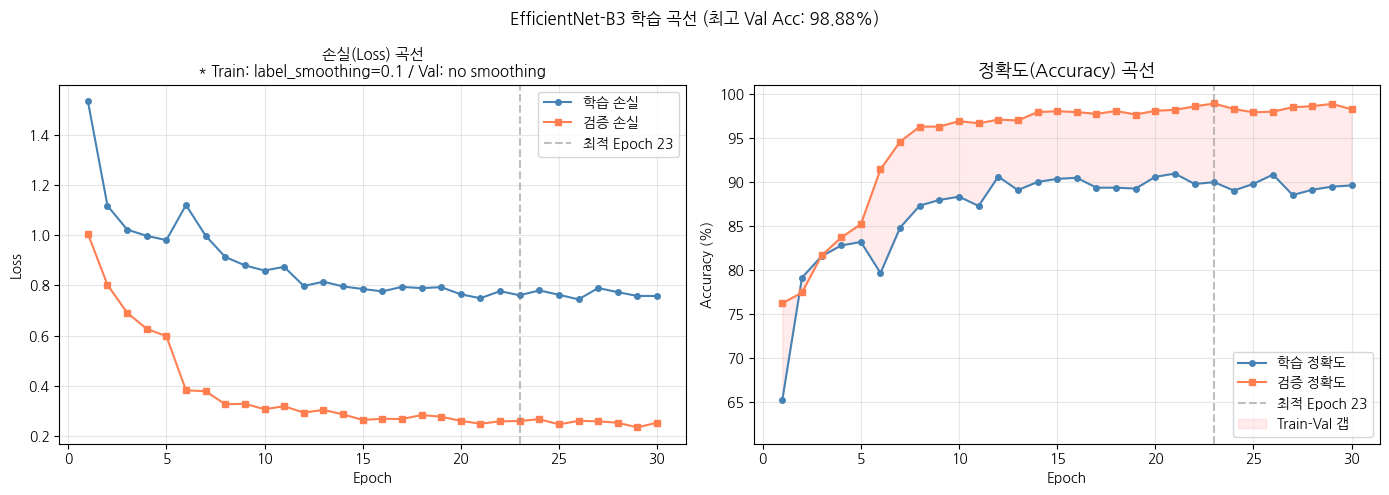

최종 Train-Val 정확도 갭: -8.65% (MixUp 적용으로 Train Acc가 낮게 측정됨 — 정상)


In [11]:
import matplotlib.pyplot as plt

epochs_ran = len(history['train_loss'])
x          = range(1, epochs_ran + 1)
best_epoch = history['val_acc'].index(max(history['val_acc'])) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss 곡선
ax1.plot(x, history['train_loss'], label='학습 손실',  color='steelblue', marker='o', markersize=4)
ax1.plot(x, history['val_loss'],   label='검증 손실',  color='coral',     marker='s', markersize=4)
ax1.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'최적 Epoch {best_epoch}')
# 수정: train/val loss 기준이 다름을 명시
ax1.set_title('손실(Loss) 곡선\n* Train: label_smoothing=0.1 / Val: no smoothing', fontsize=11)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

# Accuracy 곡선
ax2.plot(x, history['train_acc'], label='학습 정확도', color='steelblue', marker='o', markersize=4)
ax2.plot(x, history['val_acc'],   label='검증 정확도', color='coral',     marker='s', markersize=4)
ax2.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'최적 Epoch {best_epoch}')

# 수정: fill_between의 위아래를 min/max로 처리하여 음수 갭에도 올바르게 표시
train_a = history['train_acc']
val_a   = history['val_acc']
ax2.fill_between(x, train_a, val_a, alpha=0.08, color='red', label='Train-Val 갭')

min_acc = min(min(train_a), min(val_a))
ax2.set_ylim([max(0, min_acc - 5), 101])
ax2.set_title('정확도(Accuracy) 곡선', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle(f'EfficientNet-B3 학습 곡선 (최고 Val Acc: {max(history["val_acc"]):.2f}%)')
plt.tight_layout()
plt.show()

final_gap = train_a[-1] - val_a[-1]
print(f'최종 Train-Val 정확도 갭: {final_gap:.2f}%', end=' ')
if   final_gap < -2: print('(MixUp 적용으로 Train Acc가 낮게 측정됨 — 정상)')
elif final_gap >  5: print('(과적합 의심)')
else:                print('(양호)')

시스템 추론 성능 측정

In [12]:
import torch

print('=' * 60)
print('시스템 추론 성능(FPS 및 Latency) 측정 시작...')

model.eval()
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

# GPU 워밍업
with torch.no_grad():
    for _ in range(20):                     # 수정: 10 → 20 (더 안정적)
        _ = model(dummy_input)

num_iterations = 200                         # 수정: 100 → 200 (통계적 안정성)

if device.type == 'cuda':
    # ── GPU: CUDA Events로 정확한 비동기 타이밍 측정 ──────────────
    # time.time()은 CUDA 커널이 끝나기 전에 찍혀 실제보다 짧게 측정됨
    starter = torch.cuda.Event(enable_timing=True)
    ender   = torch.cuda.Event(enable_timing=True)
    torch.cuda.synchronize()
    starter.record()
    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(dummy_input)
    ender.record()
    torch.cuda.synchronize()
    avg_latency_ms = starter.elapsed_time(ender) / num_iterations
else:
    # ── CPU: time.perf_counter 사용 (time.time보다 정밀) ───────────
    import time
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(dummy_input)
    avg_latency_ms = (time.perf_counter() - start) / num_iterations * 1000

fps = 1000 / avg_latency_ms

print(f'테스트 환경 (Device): {device}')
print(f'1장당 평균 추론 시간 (Latency): {avg_latency_ms:.2f} ms')
print(f'초당 처리 프레임 (FPS): {fps:.2f} FPS')
print('=' * 60)

시스템 추론 성능(FPS 및 Latency) 측정 시작...
테스트 환경 (Device): cuda
1장당 평균 추론 시간 (Latency): 12.91 ms
초당 처리 프레임 (FPS): 77.43 FPS


데이터 군집화 시각화

t-SNE 시각화를 위한 특징(Feature) 추출 중... (약 1~2분 소요)


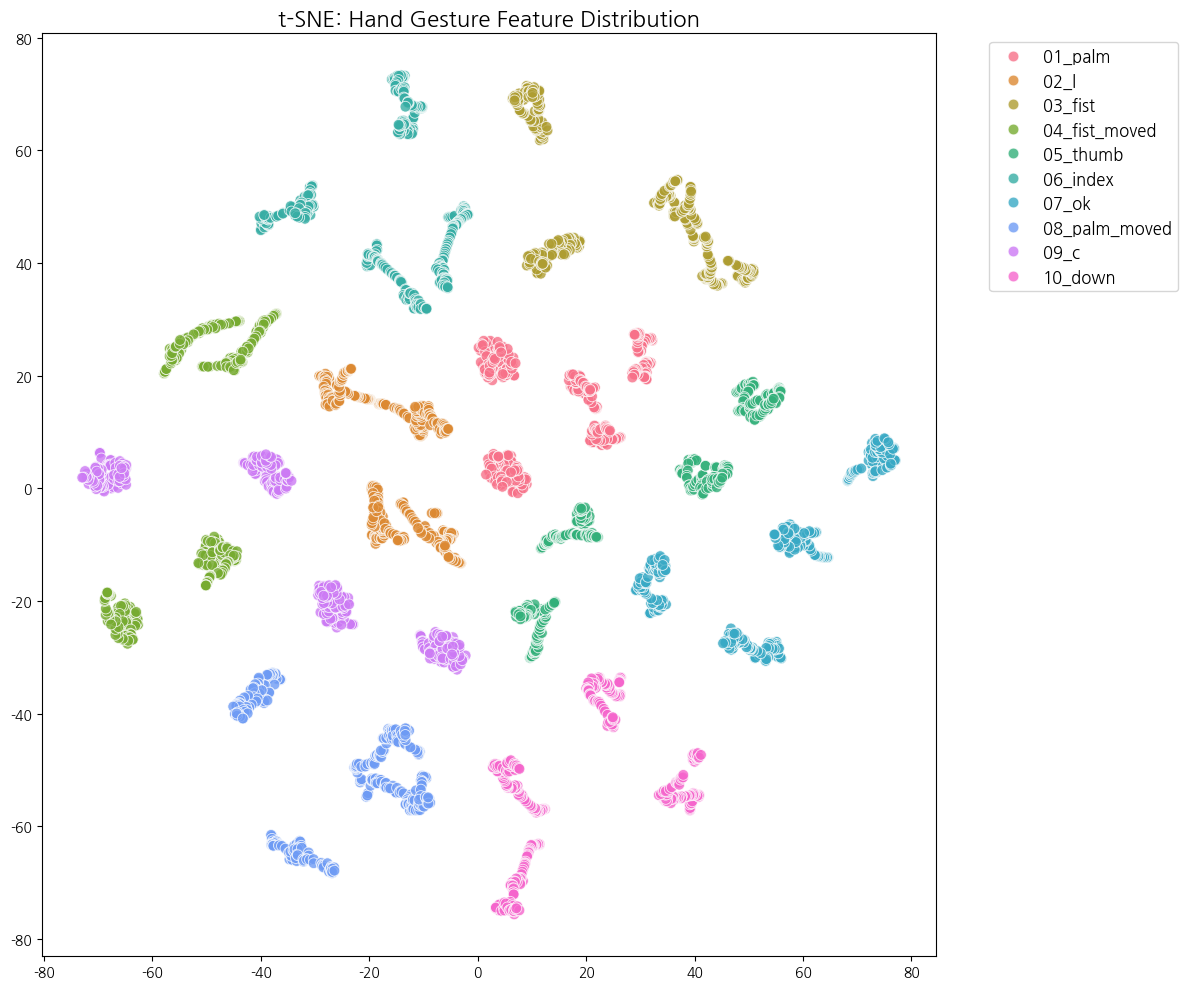

분석: 그래프에서 fist와 fist_moved가 같은 공간에 섞여있는지 확인해보세요!


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import torch.nn as nn

print('=' * 60)
print('t-SNE 시각화를 위한 특징(Feature) 추출 중... (약 1~2분 소요)')

model.eval()
features, targets = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        with autocast('cuda'):
            x = model.features(images)
            x = nn.functional.adaptive_avg_pool2d(x, (1, 1))
            x = torch.flatten(x, 1)
        features.extend(x.cpu().float().numpy())    # ← float() : AMP half precision 대응
        targets.extend(labels.cpu().numpy())

features = np.array(features)
targets  = np.array(targets)

# 수정: perplexity는 반드시 n_samples보다 작아야 함 (sklearn 요구사항)
safe_perplexity = min(30, len(features) // 4)
tsne = TSNE(n_components=2, random_state=SEED, perplexity=safe_perplexity)
tsne_results = tsne.fit_transform(features)

plt.figure(figsize=(12, 10))
palette = sns.color_palette('husl', NUM_CLASSES)
sns.scatterplot(
    x=tsne_results[:, 0], y=tsne_results[:, 1],
    hue=[train_dataset.classes[t] for t in targets],
    palette=palette, legend='full', alpha=0.8, s=60
)
plt.title('t-SNE: Hand Gesture Feature Distribution', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()
print('분석: 그래프에서 fist와 fist_moved가 같은 공간에 섞여있는지 확인해보세요!')

테스트 셋 최종 평가 (혼돈행렬)

최종 테스트 정확도: 97.35%
최종 테스트 손실:   0.3651

=== 테스트셋 최종 평가 (피험자 08, 09) ===
               precision    recall  f1-score   support

      01_palm       0.95      0.99      0.97       400
         02_l       0.99      0.98      0.98       400
      03_fist       1.00      0.91      0.95       400
04_fist_moved       0.95      1.00      0.97       400
     05_thumb       1.00      1.00      1.00       400
     06_index       1.00      0.99      0.99       400
        07_ok       1.00      0.87      0.93       400
08_palm_moved       0.88      1.00      0.94       400
         09_c       1.00      1.00      1.00       400
      10_down       1.00      1.00      1.00       400

     accuracy                           0.97      4000
    macro avg       0.98      0.97      0.97      4000
 weighted avg       0.98      0.97      0.97      4000



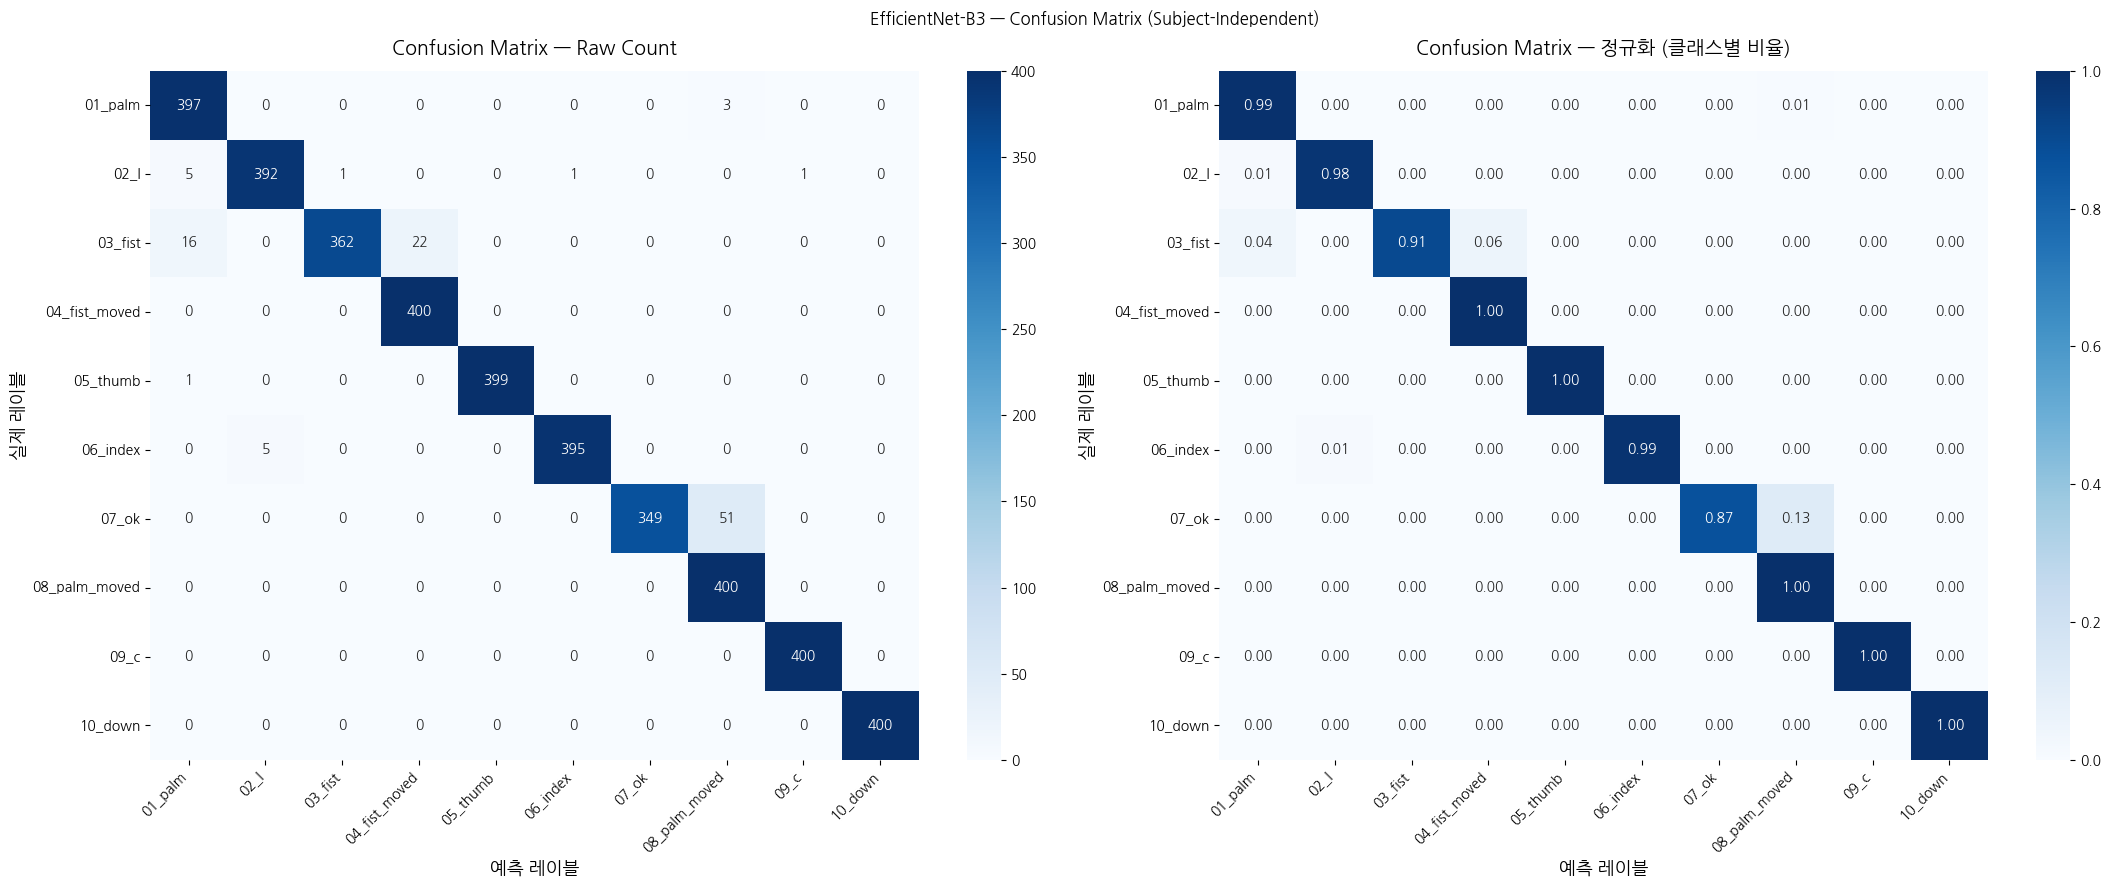

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        with autocast('cuda'):
            outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = train_dataset.classes

# 수정: classification_report 1회만 출력 (이전엔 동일한 출력이 2번 있었음)
test_loss, test_acc = evaluate(test_loader)
print(f'최종 테스트 정확도: {test_acc:.2f}%')
print(f'최종 테스트 손실:   {test_loss:.4f}')
print()
print('=== 테스트셋 최종 평가 (피험자 08, 09) ===')
print(classification_report(all_labels, all_preds, target_names=class_names))

cm      = confusion_matrix(all_labels, all_preds)
cm_norm = confusion_matrix(all_labels, all_preds, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('예측 레이블', fontsize=13, fontweight='bold')
axes[0].set_ylabel('실제 레이블', fontsize=13, fontweight='bold')
axes[0].set_title('Confusion Matrix — Raw Count', fontsize=14, pad=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_xlabel('예측 레이블', fontsize=13, fontweight='bold')
axes[1].set_ylabel('실제 레이블', fontsize=13, fontweight='bold')
axes[1].set_title('Confusion Matrix — 정규화 (클래스별 비율)', fontsize=14, pad=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.suptitle('EfficientNet-B3 — Confusion Matrix (Subject-Independent)')
plt.tight_layout()
plt.show()

예측 샘플 시각화

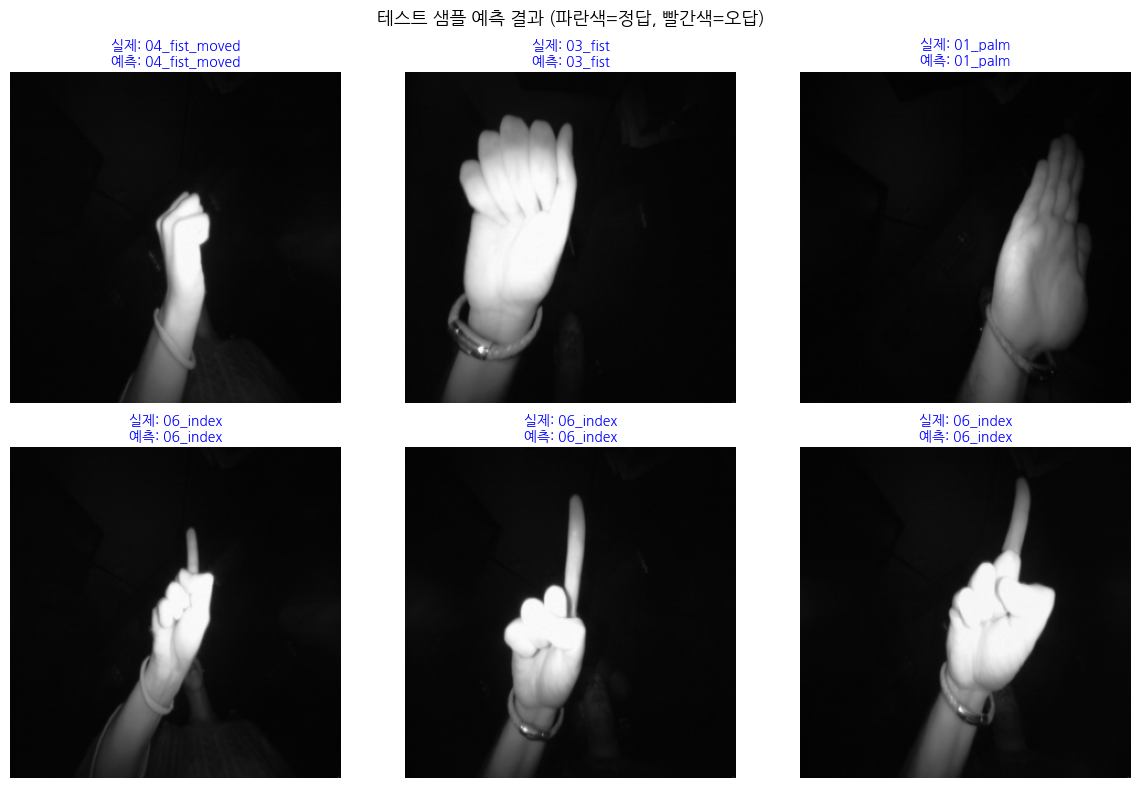

In [15]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

model.eval()
class_names = train_dataset.classes

random.seed(SEED)
indices = random.sample(range(len(test_dataset)), 6)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# 수정: 변수명 정확화 — inv_mean/inv_std는 실제 역변환이 아니라 MEAN/STD 그 자체임
denorm_mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
denorm_std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

with torch.no_grad():
    for i, idx in enumerate(indices):
        image, label = test_dataset[idx]
        img_input    = image.unsqueeze(0).to(device)
        with autocast('cuda'):
            output = model(img_input)
        _, predicted = torch.max(output, 1)

        # 역정규화: x = x_norm * std + mean
        img_display = (image * denorm_std + denorm_mean).permute(1, 2, 0).numpy()
        img_display = np.clip(img_display, 0, 1)

        true_label = class_names[label]
        pred_label = class_names[predicted.item()]
        color      = 'blue' if true_label == pred_label else 'red'

        axes[i].imshow(img_display)
        axes[i].set_title(f'실제: {true_label}\n예측: {pred_label}', color=color, fontsize=10)
        axes[i].axis('off')

plt.suptitle('테스트 샘플 예측 결과 (파란색=정답, 빨간색=오답)', fontsize=13)
plt.tight_layout()
plt.show()

Gradio 데모

In [16]:
import gradio as gr
from PIL import Image as PILImage
import random
import numpy as np
import torch

def predict_gesture(input_image):
    """PIL Image → 클래스별 확률 딕셔너리"""
    if input_image is None:
        return {}
    img_tensor = eval_transform(input_image.convert('RGB'))
    img_tensor = img_tensor.unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        with autocast('cuda'):
            output = model(img_tensor)
        probs = torch.softmax(output, dim=1).squeeze().cpu().float().numpy()
    return {train_dataset.classes[i]: float(probs[i]) for i in range(NUM_CLASSES)}

def get_random_test_sample():
    idx          = random.randint(0, len(test_dataset) - 1)
    image_tensor, label = test_dataset[idx]
    mean = np.array(IMAGENET_MEAN)
    std  = np.array(IMAGENET_STD)
    img  = image_tensor.permute(1, 2, 0).numpy()
    img  = np.clip(img * std + mean, 0, 1)
    img  = (img * 255).astype(np.uint8)
    return PILImage.fromarray(img), train_dataset.classes[label]

def predict_random_sample():
    sample_img, true_label = get_random_test_sample()
    pred_result = predict_gesture(sample_img)
    pred_label  = max(pred_result, key=pred_result.get)
    correct_text = '정답' if pred_label == true_label else '오답'
    info_text    = f'실제 라벨: {true_label}\n예측 라벨: {pred_label}\n판정: {correct_text}'
    return sample_img, pred_result, info_text

gesture_list = ', '.join(train_dataset.classes)
desc_text    = f'인식 가능 제스처: {gesture_list}'

# 수정: 두 개의 탭으로 분리 — 랜덤 테스트 탭 + 직접 업로드/웹캠 탭
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown('# 손 제스처 인식 데모 (EfficientNet-B3)')
    gr.Markdown(desc_text)

    with gr.Tab('랜덤 테스트 (Subject 08, 09)'):
        random_image  = gr.Image(label='테스트 이미지', type='pil')
        random_output = gr.Label(num_top_classes=3, label='예측 결과 (상위 3개)')
        random_info   = gr.Textbox(label='결과 분석', lines=3)
        random_btn    = gr.Button('랜덤 이미지 불러와서 예측하기', variant='primary')
        random_btn.click(fn=predict_random_sample, inputs=None,
                         outputs=[random_image, random_output, random_info])

    # 수정: 직접 업로드 또는 웹캠 탭 추가 (실시간 추론)
    with gr.Tab('직접 테스트 (업로드 / 웹캠)'):
        gr.Markdown('이미지를 업로드하거나 웹캠으로 직접 촬영하여 제스처를 인식합니다.')
        user_input  = gr.Image(label='입력 이미지', type='pil', sources=['upload', 'webcam'])
        user_output = gr.Label(num_top_classes=3, label='예측 결과 (상위 3개)')
        user_btn    = gr.Button('예측하기', variant='primary')
        user_btn.click(fn=predict_gesture, inputs=user_input, outputs=user_output)

# 수정: debug=True → debug=False (불필요한 내부 로그 노출 제거)
demo.launch(share=True, debug=False)

/tmp/ipykernel_1120/737124956.py:42: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://44a3dad06349ee8156.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
